In [2]:
import datetime
import pathlib

In [1]:
import xarray

In [36]:
import matplotlib.pyplot
import cartopy

In [6]:
root_dir = pathlib.Path('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST')
root_dir

PosixPath('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST')

In [54]:
var_dict = {
    'ta850': root_dir / 'ta850',
    'ta700': None,
    'ta500': None,
    'ua700': None,
    'va700': None,
    'zg500': None,
    'hus850': None,
    'pr': root_dir / 'pr',

}

In [ ]:
#ta850_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc

In [10]:
fname_template = '{var_name}_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_{start_dt}-{end_dt}.nc'

In [58]:
fname_pr_template

NameError: name 'fname_pr_template' is not defined

In [11]:
start_dt = datetime.datetime(2002,1,1,3,0)
start_str = f'{start_dt.year}{start_dt.month:02d}{start_dt.day:02d}{start_dt.hour:02d}00'
end_dt = datetime.datetime(2002,2,1,0,0)
end_str = f'{end_dt.year}{end_dt.month:02d}{end_dt.day:02d}{end_dt.hour:02d}00'

In [17]:
select_var = 'ta850'

In [18]:
select_var_path = var_dict[select_var] / fname_template.format(
    var_name = select_var,
    start_dt=start_str,
    end_dt=end_str,
)
select_var_path

PosixPath('/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST/ta850/ta850_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc')

In [20]:
ta850_ds = xarray.load_dataset(select_var_path)
ta850_ds 

<xarray.Dataset> Size: 2GB
Dimensions:   (lon: 2000, bnds: 2, lat: 2101, time: 120)
Coordinates:
  * lon       (lon) float64 16kB -24.52 -24.48 -24.44 -24.4 ... 56.36 56.4 56.44
  * lat       (lat) float64 17kB -45.55 -45.5 -45.46 -45.42 ... 39.42 39.46 39.5
  * time      (time) object 960B 2002-01-01 06:00:00 ... 2002-02-01 00:00:00
    plev      float64 8B 8.5e+04
Dimensions without coordinates: bnds
Data variables:
    lon_bnds  (lon, bnds) float64 32kB -24.54 -24.5 -24.5 ... 56.42 56.42 56.46
    lat_bnds  (lat, bnds) float64 34kB -45.57 -45.53 -45.53 ... 39.48 39.53
    ta850     (time, lat, lon) float32 2GB 277.1 277.1 277.0 ... 279.0 278.9
Attributes: (12/41)
    CDI:                   Climate Data Interface version 2.4.1 (https://mpim...
    Conventions:           CF-1.7 CMIP-6.2
    source:                HadREM-CP4A-4p5km (2023)
    institution:           Met Office Hadley Centre, Fitzroy Road, Exeter, De...
    activity_id:           DECK
    branch_method:         no parent
    ...                    ...
    variable_id:           ta850
    variable_name:         ta850
    variant_label:         r1i1p1f3
    license:               CP4A model data is licensed for Non-Commercial Res...
    cmor_version:          3.8.0
    CDO:                   Climate Data Operators version 2.4.1 (https://mpim...

In [22]:
ta850_ds['time'].min(), ta850_ds['time'].max()

(<xarray.DataArray 'time' ()> Size: 8B
 array(cftime.Datetime360Day(2002, 1, 1, 6, 0, 0, 0, has_year_zero=True),
       dtype=object)
 Coordinates:
     plev     float64 8B 8.5e+04,
 <xarray.DataArray 'time' ()> Size: 8B
 array(cftime.Datetime360Day(2002, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       dtype=object)
 Coordinates:
     plev     float64 8B 8.5e+04)

In [41]:
float(ta850_ds['lat'].min()), float(ta850_ds['lat'].max())

(-45.545249938964844, 39.50475311279297)

In [42]:
float(ta850_ds['lon'].min()), float(ta850_ds['lon'].max())

(-24.520263671875, 56.439239501953125)

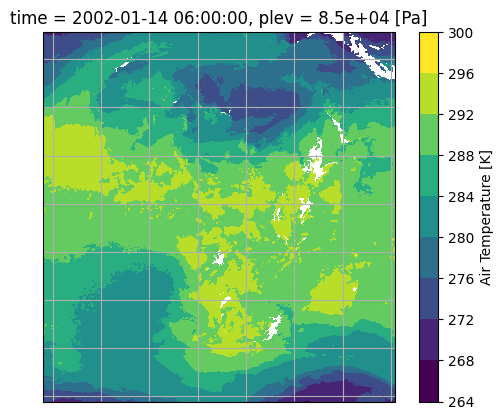

In [53]:
# fig1 = matplotlib.pyplot.figure()
# ax1 = fig1.add_subplot(1,1,1,projection=cartopy.crs.Mercator())
plot1 = ta850_ds['ta850'].loc['2002-01-14 06:00'][0].plot.contourf(subplot_kws={'projection': cartopy.crs.Mercator()})
plot1.axes.coastlines()
plot1.axes.gridlines()

In [55]:
select_var = 'pr'

In [56]:
select_var_path = var_dict[select_var] / fname_template.format(
    var_name = select_var,
    start_dt=start_str,
    end_dt=end_str,
)

In [57]:
pr_ds = xarray.load_dataset(select_var_path)

FileNotFoundError: [Errno 2] No such file or directory: '/gws/pw/j25/cp4a/HadGEM3-GC31-MM-HIST/pr/pr_GC6hrPtUV_HadREM-CP4A-4p5km_HadGEM3-GC31-MM_r1i1p1f3_gn_200201010300-200202010000.nc'